In [ ]:
#Lab 2/Ahmed Ali Alyousif/2230004696/8MA2


In [5]:
#Step 1: Import the libraries

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [30]:
#Task1: Change the sampling and quantization parameters and observe the effects.
def sample_image(image, factor):
    height, width = image.shape[:2]
    sampled_image = cv2.resize(
        image, 
        (width // factor, height // factor), 
        interpolation=cv2.INTER_NEAREST
    )
    return sampled_image


def quantize_image(image, levels):
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    return quantized_image.astype(np.uint8)


def show_two_inputs_and_result(img1, img2, result, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img1, cmap='gray')
    plt.title("Image A")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(img2, cmap='gray')
    plt.title("Image B")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(result, cmap='gray')
    plt.title(title)
    plt.axis('off')

    plt.show()



In [27]:
image_path = 'output.png'
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    print("Error loading image")


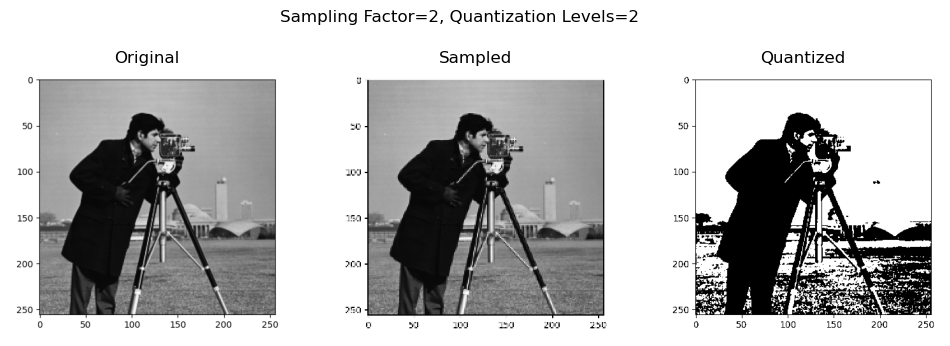

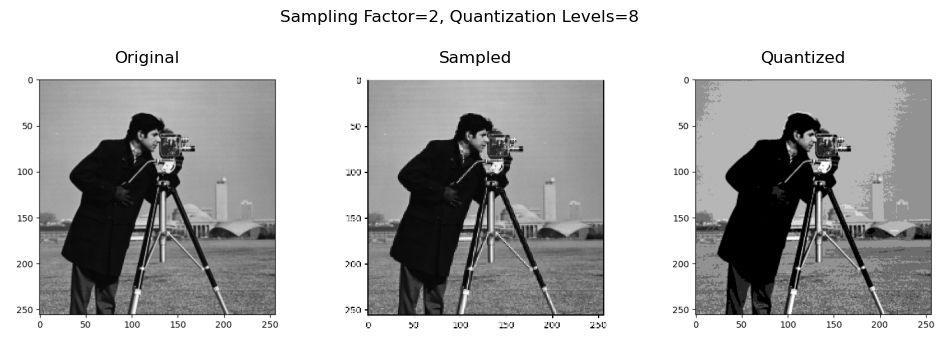

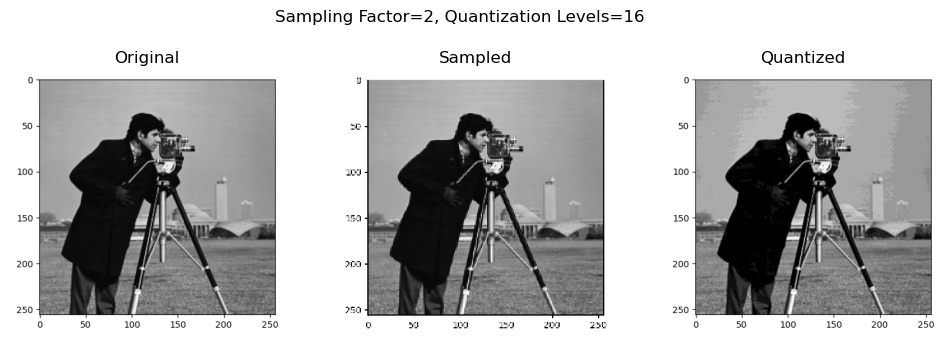

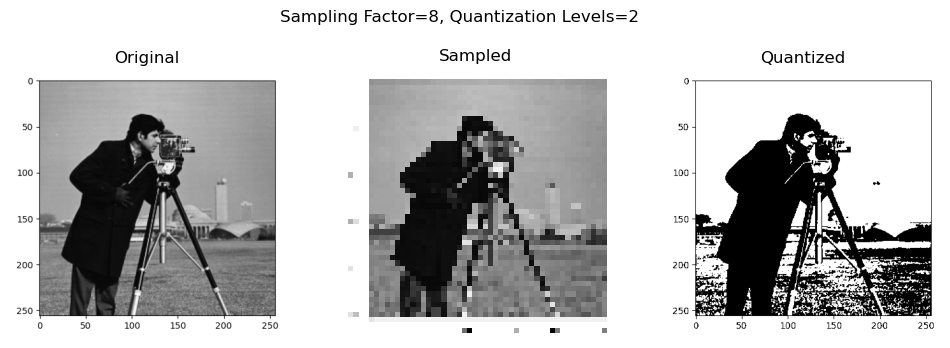

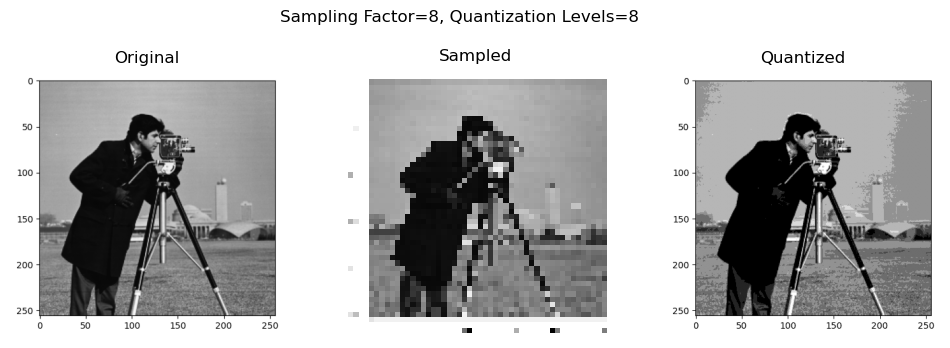

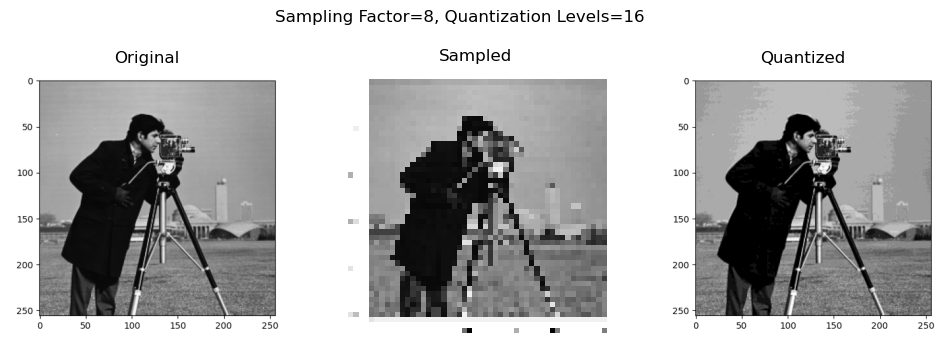

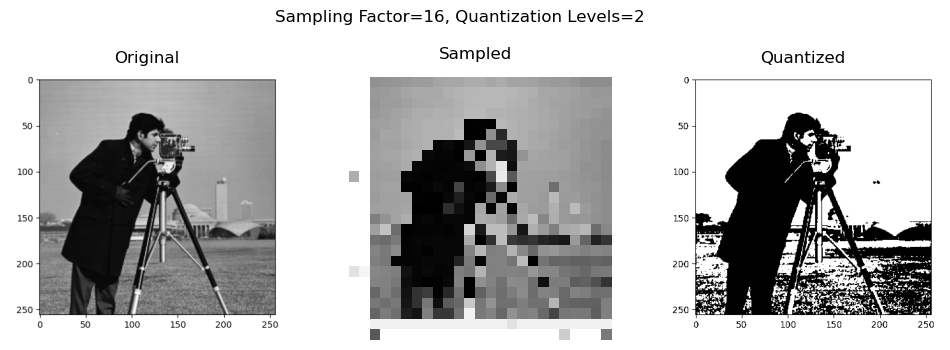

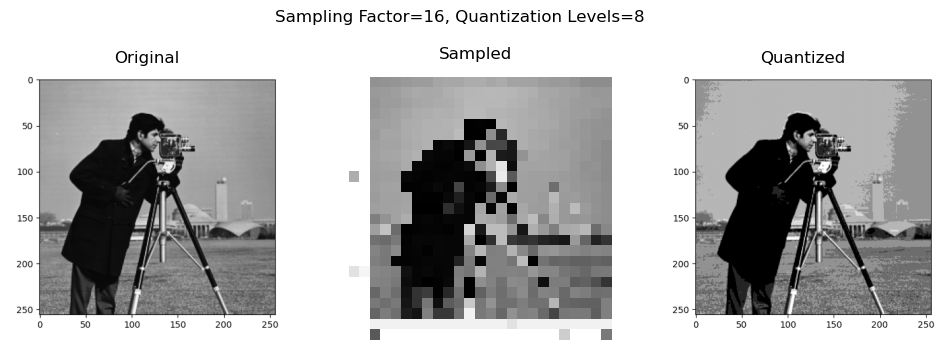

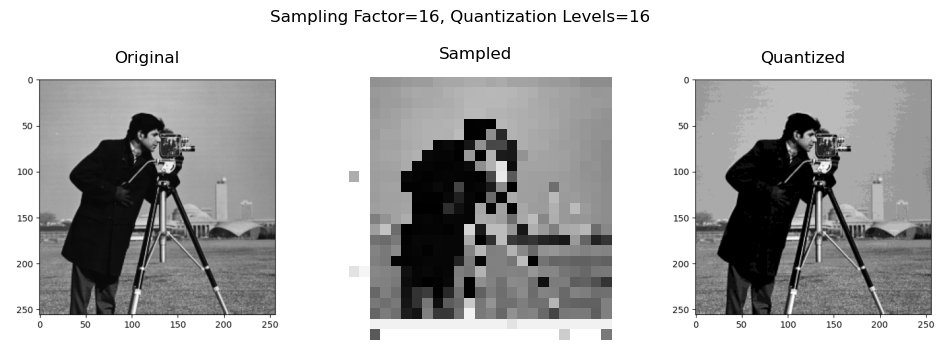

In [28]:
sampling_factors = [2, 8, 16]
quantization_levels = [2, 8, 16]

for sf in sampling_factors:
    for ql in quantization_levels:
        sampled = sample_image(original_image, sf)
        quantized = quantize_image(original_image, ql)
        plot_images(
            original_image,
            sampled,
            quantized,
            title=f"Sampling Factor={sf}, Quantization Levels={ql}"
        )


In [19]:
'''Task#2: Read two images, convert them into an array, and perform the following 
operations on them. 
1. Subtract two images and display the result.
2. Add one image with a constant value of 175 and display it.
3. Apply the set difference operation on two Gray-Scale images. 
4. Apply the symmetric difference operation on two Gray-Scale images. 
5. Apply Intersection operations on two Gray-Scale images. '''

from PIL import Image

img1 = Image.open('output.png').convert('L')
img2 = Image.open('output4.png').convert('L')

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1 = np.array(img1)
im2 = np.array(img2)


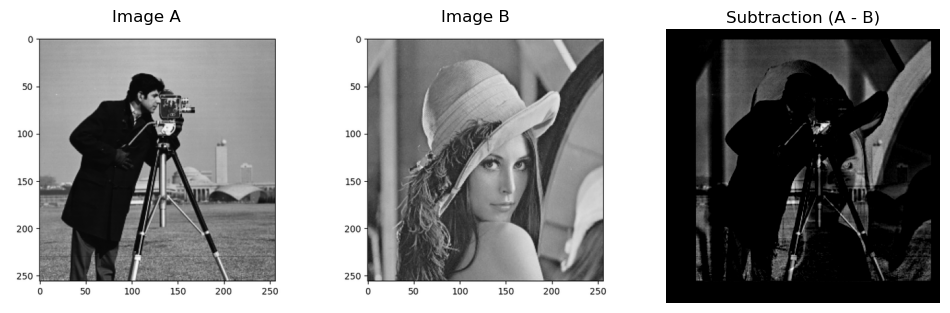

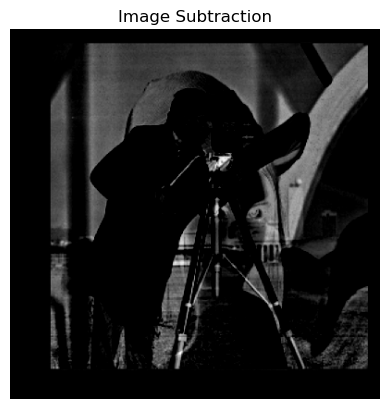

In [31]:
#Task 2.1
subtraction = cv2.subtract(im1, im2)
show_two_inputs_and_result(im1, im2, subtraction, "Subtraction (A - B)")
plt.imshow(subtraction, cmap='gray')
plt.title("Image Subtraction")
plt.axis('off')
plt.show()


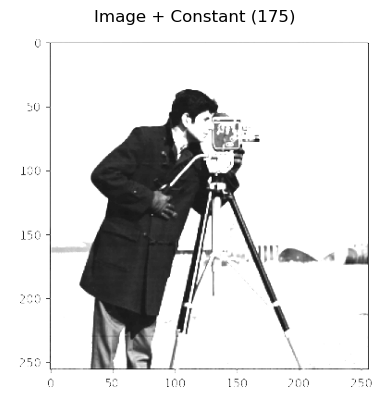

In [32]:
#Task 2.2
constant_add = cv2.add(im1, 175)
plt.imshow(constant_add, cmap='gray')
plt.title("Image + Constant (175)")
plt.axis('off')
plt.show()


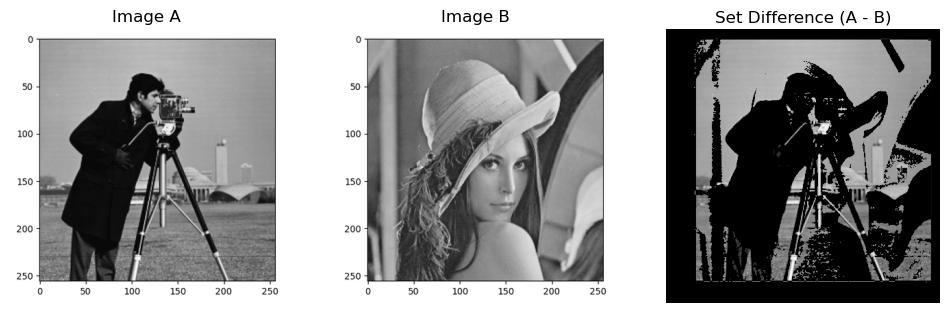

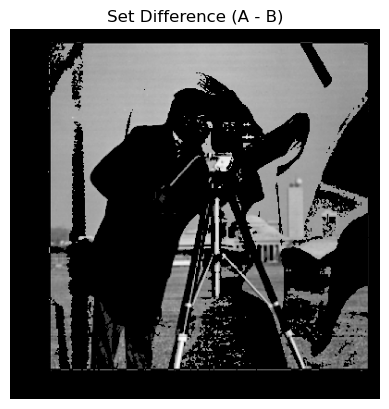

In [33]:
#Task 2.3
set_difference = np.where(im1 > im2, im1, 0)
show_two_inputs_and_result(im1, im2, set_difference, "Set Difference (A - B)")
plt.imshow(set_difference, cmap='gray')
plt.title("Set Difference (A - B)")
plt.axis('off')
plt.show()


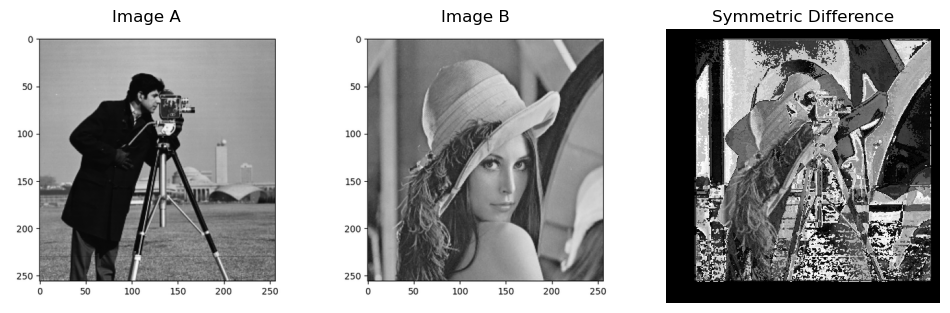

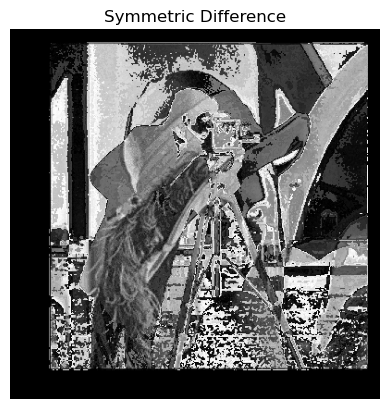

In [34]:
#Task 2.4
sym_diff = np.bitwise_xor(im1, im2)
show_two_inputs_and_result(im1, im2, sym_diff, "Symmetric Difference")

plt.imshow(symmetric_difference, cmap='gray')
plt.title("Symmetric Difference")
plt.axis('off')
plt.show()


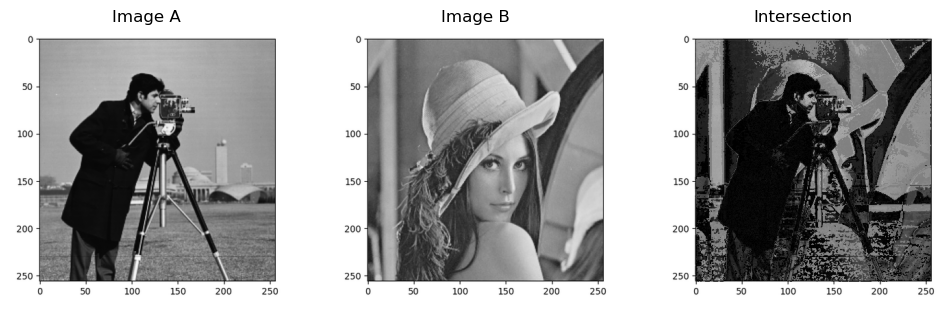

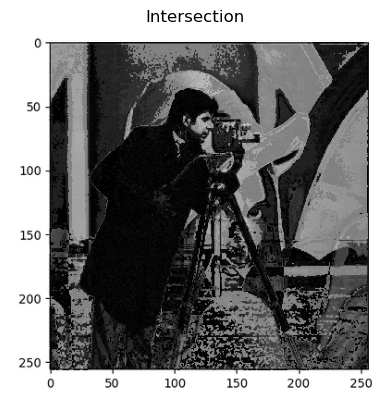

In [35]:
#Task 2.5
intersection = np.bitwise_and(im1, im2)
show_two_inputs_and_result(im1, im2, intersection, "Intersection")
plt.imshow(intersection, cmap='gray')
plt.title("Intersection")
plt.axis('off')
plt.show()
